# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: PolynomialEmbedding (n=3)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [1]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import jax
import jax.numpy as jnp
import numpy as np
import optax
import torch
import quimb.tensor as qtn
from sklearn.metrics import auc
from jax.nn.initializers import *
import matplotlib.pyplot as plt

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *



from cascaded_tn.training.cascaded_model import *
from cascaded_tn.builders.dimension_calculator import DimensionCalculator

In [2]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
print("JAX devices:", jax.devices())
print("JAX device kind:", jax.devices()[0].device_kind)
print("PyTorch CUDA:", torch.cuda.is_available())

JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]
JAX device kind: NVIDIA A100-SXM4-40GB
PyTorch CUDA: True


**Load 40 MHz dataset**

In [3]:
import utils.dataloader as d

inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/" #Change this based on wherever your datasets are located.
print(os.environ["HDF5_USE_FILE_LOCKING"]) #This should be false, otherwise there might be issues with reading the hdf5 files.

FALSE


In [4]:
batch_size = 4000
background = d.load_data(inputPath + "background_for_training.h5", batch_size=batch_size, shuffle=True, norm=True)

In [5]:
print("Background shape before:", next(iter(background)).shape)

Background shape before: torch.Size([4000, 56])


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [33]:
# define model parameters
L = 56
initializer = jax.nn.initializers.variance_scaling(scale=2.0, mode='fan_avg', distribution='uniform')
key = jax.random.PRNGKey(42)

k = 2
# embedding = PolynomialEmbedding(degree=k, n=1, include_bias=True)
embedding = TrigonometricEmbedding(k)
phys_dim = (embedding.dim, embedding.dim) # = (2k, 2k) for trigonometric embedding, (k+1, k+1) for polynomial embedding

add_identity = True
boundary='obc' # 'pbc' or 'obc' = periodic or open boundary conditions

In [ ]:
def AsymmetricLogNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """Asymmetric loss combining log behavior for small norms and polynomial for large norms.
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedSquaredNorm(model, data)  # This is ||compressed||^4
    
    # For x < 1: log penalty prevents collapse
    # For x > 1: add quadratic growth for strong anomaly separation
    log_term = jax.lax.log(x)
    excess = jax.lax.max(0.0, x - 1.0)  # Only penalize when x > 1
    
    return jax.lax.pow(log_term, 2) + jax.lax.pow(excess, 2)

In [35]:
from cascaded_tn.training.regularization import LogAnomalyRegNorm

alpha = 0.4
def loss_combined(*args, **kwargs):
    error = AsymmetricLogNorm
    reg = lambda P: alpha * LogAnomalyRegNorm(
        P, 
        alpha_spectral=0.01,
        alpha_smooth=0.2,
        alpha_sparse=0.2
    )
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [ ]:
# calc = DimensionCalculator(debug=False)
autoencoder = create_trainable_autoencoder(
    # layer_dims=calc.suggest_cyclic_compatible_dims(56, 3, target_output=3),
    layer_dims=[56,19,7,3],
    bond_dims=[2,2,2],
    cyclic=False,
    symmetric=False,
    key=key,
    debug=False,
    initializer=initializer,
    phys_dim=phys_dim,
    add_identity=add_identity,
    boundary=boundary,
    optimizer=optax.adam,
    learning_rate=1e-2,
    loss_function=loss_combined,
)
autoencoder.device = 'gpu'

In [37]:
print("Number of parameters in the model are: ", autoencoder.nparams())

Number of parameters in the model are:  30176


In [38]:
def loss_fn(data, targets, *params):

    temp_model = autoencoder.copy()

    # Update with new parameters
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)

    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)

    # Apply the cascade (compression only for now)
    compressed = temp_model.cascade.apply(tn_i)
    
    return autoencoder.loss(compressed, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*autoencoder.L), backend=autoencoder.device)

In [ ]:
# Split into two parts: data-dependent and model-dependent

@jax.jit
def compute_error_batch(sample_batch, *params):
    """JIT-compiled error computation for the batch"""
    def single_error(data_point, *p):
        # Create temp model and update params
        temp_model = autoencoder.copy()
        for tensor, param in zip(temp_model.tensors, p):
            tensor.modify(data=param)
        
        # Compute error for single point
        tn_i = embed(data_point, embedding)
        compressed = temp_model.cascade.apply(tn_i)
        return AsymmetricLogNorm(compressed, tn_i)
    
    # Vectorize over batch
    errors = jax.vmap(single_error, in_axes=[0] + [None]*len(params))(sample_batch, *params)
    return jnp.mean(errors)

# Separate function for regularization (computed ONCE, not per batch item!)
def compute_reg_components_fast(*params):
    """Compute regularization terms - only needs to run once per parameter update"""
    # Pre-compute tensor shapes and indices outside JIT
    tensor_shapes = [t.shape for t in autoencoder.tensors]
    layer_boundaries = []  # Store which tensors belong to which layer
    
    # Figure out tensor-to-layer mapping
    idx = 0
    for op in autoencoder.cascade.operators:
        if hasattr(op.implementation, 'tensors'):
            n_tensors = len(op.implementation.tensors)
            layer_boundaries.append((idx, idx + n_tensors))
            idx += n_tensors
    
    @jax.jit
    def reg_terms(params_concat):
        """JIT-compiled regularization computation"""
        # Split concatenated params back into individual tensors
        params_list = []
        start = 0
        for shape in tensor_shapes:
            size = np.prod(shape)
            param = params_concat[start:start+size].reshape(shape)
            params_list.append(param)
            start += size
        
        reg_spectral = reg_smooth = reg_sparse = 0.0
        prev_norm = None
        
        # Process each layer
        for layer_idx, (start_idx, end_idx) in enumerate(layer_boundaries):
            layer_tensors = params_list[start_idx:end_idx]
            
            # 1. Spectral regularization
            for tensor in layer_tensors:
                if len(tensor.shape) >= 2:
                    matrix = tensor.reshape(tensor.shape[0], -1)
                    s = jnp.linalg.svd(matrix, compute_uv=False)
                    effective_rank = jnp.sum(s) ** 2 / (jnp.sum(s ** 2))
                    reg_spectral += (1.0 / (effective_rank + 0.1))
            
            # 2. Layer smoothness
            curr_norm = sum(jnp.sum(t**2) for t in layer_tensors)
            if layer_idx > 0 and prev_norm is not None:
                reg_smooth += jnp.abs(jnp.log(curr_norm / (prev_norm)))
            prev_norm = curr_norm
            
            # 3. Bottleneck sparsity (last layer)
            if layer_idx == len(layer_boundaries) - 1:
                for tensor in layer_tensors:
                    reg_sparse += jnp.sum(jnp.abs(tensor))
        
        return reg_spectral, reg_smooth, reg_sparse
    
    # Concatenate all parameters into single array
    params_concat = jnp.concatenate([p.flatten() for p in params])
    
    return reg_terms(params_concat)

In [40]:
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+autoencoder.L)), in_axes=[0, None] + [None]*autoencoder.L), backend=autoencoder.device)

params = autoencoder.arrays
autoencoder.step, autoencoder.opt_state = autoencoder.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)

In [41]:
@jax.jit
def train_step_jitted(params, opt_state, batch):
    # Compute loss and gradients in one go
    loss_val, grads = jax.value_and_grad(
        lambda *p: jnp.mean(jax.vmap(loss_fn, in_axes=[0, None] + [None]*len(p))(batch, None, *p)),
        argnums=range(len(params))
    )(*params)
    
    # Update parameters
    grads_dict = {i: g for i, g in enumerate(grads)}
    params_dict = {i: p for i, p in enumerate(params)}
    
    updates, opt_state = autoencoder.optimizer.update(grads_dict, opt_state)
    params_dict = optax.apply_updates(params_dict, updates)
    
    return tuple(params_dict.values()), opt_state, loss_val

In [42]:
from tqdm import tqdm
import time

epochs = 2
history = {'learning_rate': 1e-4, 
            'loss': [], 
            'error_term' : [],
            'spectral_term': [],
            'smooth_term': [],
            'sparse_term': [],
            'epoch_time': [], 
            'unfinished': True}

autoencoder.cascade.debug = False
autoencoder.debug = False
for op in autoencoder.cascade.operators:
    op.debug = False
    if hasattr(op, 'implementation'):
        op.implementation.debug = False

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    sample_batch = None  # Store one batch for loss component analysis

    for i, batch in enumerate(tqdm(background, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        if sample_batch is None:  # Save first batch for analysis
            sample_batch = batch
        params = autoencoder.arrays
        params, autoencoder.opt_state, loss = train_step_jitted(params, autoencoder.opt_state, batch)
        autoencoder.update_tensors(params)
        epoch_loss += loss

    end_time = time.time()
    avg_loss = epoch_loss / len(background)

    # Compute individual loss terms for monitoring using the existing loss functions
    # Get current model parameters
    current_params = autoencoder.arrays

    error_val = float(compute_error_batch(sample_batch, *autoencoder.arrays))

    reg_spectral, reg_smooth, reg_sparse = compute_reg_components_fast(*autoencoder.arrays)
    reg_spectral = float(reg_spectral)
    reg_smooth = float(reg_smooth)
    reg_sparse = float(reg_sparse)

    history['loss'].append(avg_loss)
    history['error_term'].append(error_val)
    history['spectral_term'].append(reg_spectral)
    history['smooth_term'].append(reg_smooth)
    history['sparse_term'].append(reg_sparse)
    history['epoch_time'].append(end_time - start_time)
    
    print(f"[Epoch {epoch+1}] Loss: {avg_loss:.6f} | Error: {error_val:.6f} | Spectral: {reg_spectral:.6f} | Smooth: {reg_smooth:.6f} | Sparse: {reg_sparse:.6f} | Time: {end_time - start_time:.2f}s")
    history['unfinished'] = False  # training completed successfully


Epoch 1/2:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/2: 100%|██████████| 1000/1000 [01:38<00:00, 10.17it/s]


[Epoch 1] Loss: 339.321479 | Error: 339.321479 | Spectral: 19.183210 | Smooth: 3.470783 | Sparse: 40.423066 | Time: 98.31s


Epoch 2/2: 100%|██████████| 1000/1000 [01:23<00:00, 12.05it/s]


[Epoch 2] Loss: 339.321479 | Error: 339.321479 | Spectral: 19.183210 | Smooth: 3.470783 | Sparse: 40.423066 | Time: 83.02s


In [43]:
# After one training step, check a few compressed outputs
for i in range(3):
    data_jax = jnp.array(next(iter(background))[0])
    input_mps = embed(data_jax, embedding)
    compressed = autoencoder.cascade.apply(input_mps)
    print(f"Sample {i} compressed norm: {compressed.norm()}")


Sample 0 compressed norm: 5.549232745066807e-25
Sample 1 compressed norm: 6.686156379605476e-25
Sample 2 compressed norm: 3.1791579549503118e-25


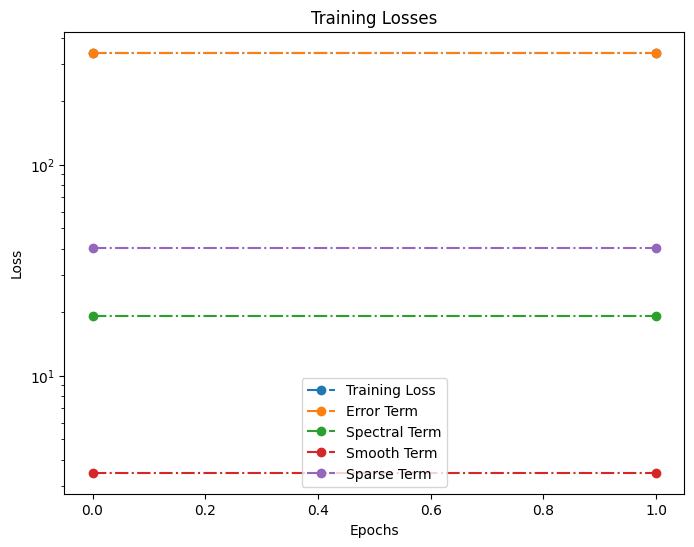

In [44]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='Training Loss')
plt.plot(range(len(history['error_term'])), history['error_term'], linestyle="-.", marker='o', label='Error Term')
plt.plot(range(len(history['spectral_term'])), history['spectral_term'], linestyle="-.", marker='o', label='Spectral Term')
plt.plot(range(len(history['smooth_term'])), history['smooth_term'], linestyle="-.", marker='o', label='Smooth Term')
plt.plot(range(len(history['sparse_term'])), history['sparse_term'], linestyle="-.", marker='o', label='Sparse Term')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.savefig('training_loss.png', dpi=300)

**Evaluate**

In [45]:
a4l = d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, shuffle=True, norm=True)
lq = d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, shuffle=True, norm=True)
htnu = d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, shuffle=True, norm=True)
htt = d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, shuffle=True, norm=True)

In [46]:
@jax.jit
def loss_error_only(data, targets, *params):
    """Compute only AsymmetricLogNorm error term for anomaly scoring"""
    # Create temp model with updated parameters
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)
    
    # Apply the cascade
    compressed = temp_model.cascade.apply(tn_i)
    
    # Return only error term (no regularization)
    return AsymmetricLogNorm(compressed, tn_i)

# Vectorize it for batch processing
loss_func_error = jax.jit(jax.vmap(loss_error_only, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

    return np.concatenate(all_scores)#, total_loss / total_samples


In [47]:
# Run the evaluation on bkg and signals
bkg_score = evaluate_model(autoencoder, background, loss_func_error, embedding, verbose=True)
a4l_score = evaluate_model(autoencoder, a4l, loss_func_error, embedding, verbose=True)
lq_score = evaluate_model(autoencoder, lq, loss_func_error, embedding, verbose=True)
htnu_score = evaluate_model(autoencoder, htnu, loss_func_error, embedding, verbose=True)
htt_score  = evaluate_model(autoencoder, htt, loss_func_error, embedding, verbose=True)

Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1000 [00:03<?, ?it/s]


KeyboardInterrupt: 

**Plot anomaly scores and ROC curve**

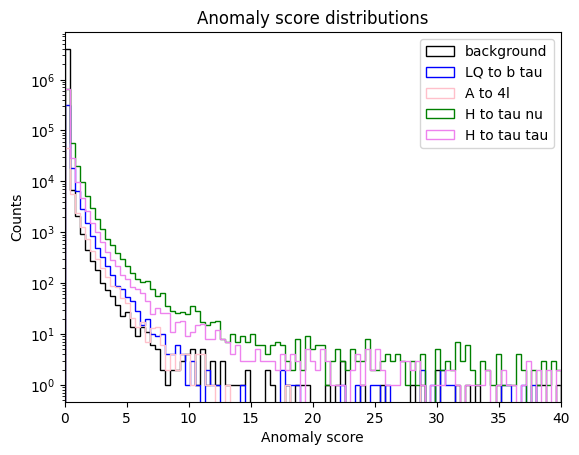

In [ ]:
plt.figure()
plt.yscale('log')
xmax = 40
bins = np.linspace(0, xmax, 100)
plt.hist(bkg_score, bins=bins, histtype='step', color='black', label='background')
plt.hist(lq_score, bins=bins, histtype='step', color='blue', label='LQ to b tau')
plt.hist(a4l_score, bins=bins, histtype='step', color='pink', label='A to 4l')
plt.hist(htnu_score, bins=bins, histtype='step', color='green', label='H to tau nu')
plt.hist(htt_score, bins=bins, histtype='step', color='violet', label='H to tau tau')
plt.title('Anomaly score distributions')
plt.xlim([0, xmax])
plt.xlabel('Anomaly score')
plt.ylabel('Counts')
plt.legend()
plt.legend()
plt.savefig('anomaly_scores.png', dpi=300)

In [ ]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 19.421472288160007


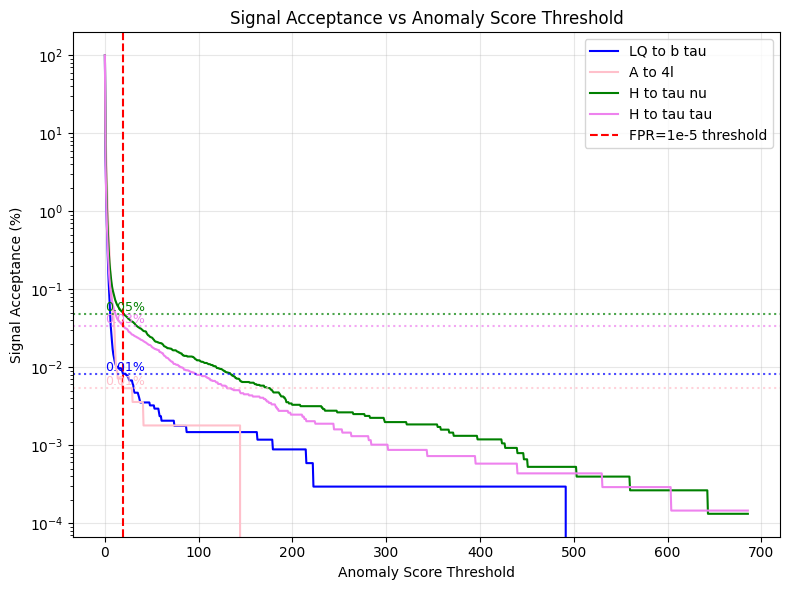

In [ ]:
# Compute acceptance curves for each signal as a function of anomaly score threshold
thresholds = np.linspace(np.min(bkg_score), np.max(bkg_score), 1000)

def acceptance_curve(scores, thresholds):
   return np.array([(scores >= t).mean() for t in thresholds])

accept_lq = acceptance_curve(lq_score, thresholds)
accept_a4l = acceptance_curve(a4l_score, thresholds)
accept_htt = acceptance_curve(htt_score, thresholds)
accept_htnu = acceptance_curve(htnu_score, thresholds)

plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(thresholds, accept_lq * 100, color="blue", label="LQ to b tau")
plt.plot(thresholds, accept_a4l * 100, color="pink", label="A to 4l")
plt.plot(thresholds, accept_htnu * 100, color="green", label="H to tau nu")
plt.plot(thresholds, accept_htt * 100, color="violet", label="H to tau tau")
# Add horizontal lines and text for acceptance at score_threshold for each signal
for accept, label, color in [
   (accept_lq, "LQ to b tau", "blue"),
   (accept_a4l, "A to 4l", "pink"),
   (accept_htnu, "H to tau nu", "green"),
   (accept_htt, "H to tau tau", "violet"),
]:
   idx = np.searchsorted(thresholds, score_threshold, side="left")
   if idx >= len(accept):
      idx = -1
   acc_val = accept[idx] * 100
   plt.axhline(y=acc_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(thresholds[0], acc_val, f"{acc_val:.2f}%", color=color, va="bottom", fontsize=9)
plt.axvline(score_threshold, color='red', linestyle='--', label='FPR=1e-5 threshold')
plt.xlabel("Anomaly Score Threshold")
plt.ylabel("Signal Acceptance (%)")
plt.title("Signal Acceptance vs Anomaly Score Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('signal_acceptance.png', dpi=300)

In [ ]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

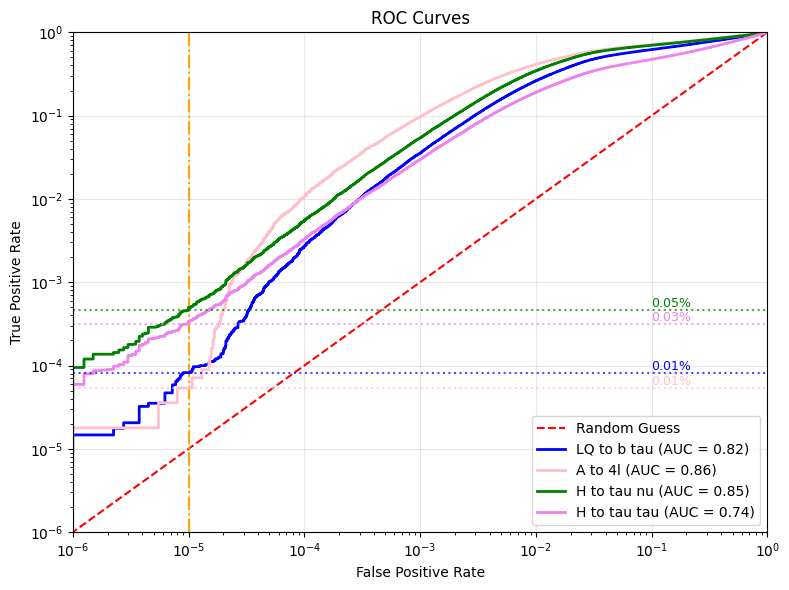

In [ ]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="left")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)

In [ ]:
def dump_model_trace(model, data_event, embedding, output_file="model_trace.json"):
    """
    Dump complete model execution trace to JSON with all weights and clear structure.
    
    Args:
        model: Your trained autoencoder model
        data_event: Single input event (shape: [56])
        embedding: The embedding object (TrigonometricEmbedding)
        output_file: Output JSON filename
    """
    import json
    import numpy as np
    import jax.numpy as jnp
    from tn4ml.embeddings import embed
    import os
    
    # Convert torch tensor to numpy if needed
    if hasattr(data_event, 'cpu'):  # It's a torch tensor
        data_event = data_event.cpu().numpy()
    elif hasattr(data_event, '__array__'):  # It's a JAX array
        data_event = np.array(data_event)
    
    print(f"Dumping trace for input shape {data_event.shape}...")
    
    # Get cascade
    cascade = model.cascade
    
    # Get actual architecture
    layer_dims = [cascade.operators[0].config.input_dim]
    layer_dims.extend([op.config.output_dim for op in cascade.operators])
    
    # Initialize trace
    trace = {
        "architecture": " → ".join(str(d) for d in layer_dims),
        "input_raw": {
            "shape": list(data_event.shape),
            "values": data_event.tolist()
        },
        "layers": [],
        "intermediate_outputs": []
    }
    
    # Step 1: Embed input
    data_jax = jnp.array(data_event)
    input_mps = embed(data_jax, embedding)
    
    # Store embedded input
    embedded = {
        "description": f"MPS representation of embedded input (56 sites, phys_dim={embedding.dim})",
        "num_tensors": len(input_mps.tensors),
        "tensors": []
    }
    
    for i, tensor in enumerate(input_mps.tensors):
        data_array = np.array(tensor.data)
        tensor_info = {
            "tensor_idx": i,
            "shape": list(tensor.shape),
            "indices": list(tensor.inds) if hasattr(tensor, 'inds') else None,
        }
        
        # Format values based on tensor structure
        if len(data_array.shape) == 2:  # Edge tensor [bond, phys]
            tensor_info["values"] = {
                "format": "[bond, phys]",
                "data": [data_array[b, :].tolist() for b in range(data_array.shape[0])]
            }
        elif len(data_array.shape) == 3:  # Middle tensor [left_bond, right_bond, phys]
            tensor_info["values"] = {
                "format": "[left_bond, right_bond, phys]",
                "data": []
            }
            for l in range(data_array.shape[0]):
                bond_slice = []
                for r in range(data_array.shape[1]):
                    bond_slice.append(data_array[l, r, :].tolist())
                tensor_info["values"]["data"].append(bond_slice)
        else:
            tensor_info["values"] = data_array.tolist()
        
        embedded["tensors"].append(tensor_info)
    
    trace["input_embedded"] = embedded
    
    # Step 2: Go through each layer
    current_mps = input_mps
    
    for layer_idx, operator in enumerate(cascade.operators):
        print(f"  Processing layer {layer_idx}: {operator.config.input_dim} → {operator.config.output_dim}")
        
        # Store layer info and ALL weights
        layer_info = {
            "index": layer_idx,
            "type": operator.operation_type if hasattr(operator, 'operation_type') else 'unknown',
            "dims": f"{operator.config.input_dim} → {operator.config.output_dim}",
            "bond_dim": operator.config.bond_dim,
            "weights": []
        }
        
        # Get tensors from operator
        if hasattr(operator, 'implementation') and hasattr(operator.implementation, 'tensors'):
            tensors = operator.implementation.tensors
        elif hasattr(operator, 'tensors'):
            tensors = operator.tensors
        else:
            tensors = []
        
        # Store ALL weights with clear formatting
        for t_idx, tensor in enumerate(tensors):
            weight_data = np.array(tensor.data)
            weight_info = {
                "tensor_idx": t_idx,
                "shape": list(weight_data.shape),
                "size": weight_data.size,
                "indices": list(tensor.inds) if hasattr(tensor, 'inds') else None,
            }
            
            # Format based on tensor type
            if len(weight_data.shape) == 3:  # [bond, phys_up, phys_down]
                weight_info["format"] = "[bond, phys_up, phys_down]"
                weight_info["values"] = []
                for b in range(weight_data.shape[0]):
                    weight_info["values"].append({
                        "bond_idx": b,
                        "phys_matrix": weight_data[b, :, :].tolist()
                    })
            elif len(weight_data.shape) == 4:  # [left_bond, right_bond, phys_up, phys_down]
                weight_info["format"] = "[left_bond, right_bond, phys_up, phys_down]"
                if weight_data.size < 1000:  # Full data for small tensors
                    weight_info["values"] = []
                    for l in range(weight_data.shape[0]):
                        left_slice = []
                        for r in range(weight_data.shape[1]):
                            left_slice.append({
                                "indices": f"[{l},{r},:,:]",
                                "phys_matrix": weight_data[l, r, :, :].tolist()
                            })
                        weight_info["values"].append(left_slice)
                else:  # Truncate for large tensors
                    weight_info["values"] = {
                        "truncated": True,
                        "showing": "corners only",
                        "top_left": weight_data[0, 0, :, :].tolist(),
                        "stats": {
                            "min": float(weight_data.min()),
                            "max": float(weight_data.max()),
                            "mean": float(weight_data.mean()),
                            "std": float(weight_data.std())
                        }
                    }
            else:
                # Fallback for other shapes
                if weight_data.size < 200:
                    weight_info["values"] = weight_data.tolist()
                else:
                    weight_info["values"] = {
                        "truncated": True,
                        "first_100": weight_data.flatten()[:100].tolist(),
                        "shape_original": list(weight_data.shape)
                    }
            
            layer_info["weights"].append(weight_info)
        
        trace["layers"].append(layer_info)
        
        # Apply operator and store result
        output_mps = operator.apply(current_mps)
        
        # Store intermediate output
        intermediate = {
            "after_layer": layer_idx,
            "output_dim": operator.config.output_dim,
            "num_mps_tensors": len(output_mps.tensors),
            "mps_tensors": []
        }
        
        for i, tensor in enumerate(output_mps.tensors):
            data = np.array(tensor.data)
            tensor_data = {
                "tensor_idx": i,
                "shape": list(data.shape),
                "indices": list(tensor.inds) if hasattr(tensor, 'inds') else None,
                "norm": float(np.linalg.norm(data)),
            }
            
            # Format values clearly
            if len(data.shape) == 2 and data.size < 500:
                tensor_data["values"] = {
                    "format": f"[{data.shape[0]}, {data.shape[1]}]",
                    "data": data.tolist()
                }
            elif len(data.shape) == 3 and data.size < 500:
                tensor_data["values"] = {
                    "format": f"[{data.shape[0]}, {data.shape[1]}, {data.shape[2]}]",
                    "data": []
                }
                for i in range(data.shape[0]):
                    tensor_data["values"]["data"].append(data[i, :, :].tolist())
            else:
                # For large tensors, show sample
                tensor_data["values"] = {
                    "size": data.size,
                    "first_50_flat": data.flatten()[:50].tolist()
                }
            
            intermediate["mps_tensors"].append(tensor_data)
        
        trace["intermediate_outputs"].append(intermediate)
        current_mps = output_mps
    
    # Step 3: Final output (contracted)
    final_contracted = current_mps.contract(all, optimize='auto-hq')
    final_output = np.array(final_contracted.data if hasattr(final_contracted, 'data') else final_contracted)
    
    trace["output_final"] = {
        "shape": list(final_output.shape),
        "values": final_output.flatten().tolist()
    }
    
    # Add summary
    trace["summary"] = {
        "architecture": layer_dims,
        "num_layers": len(cascade.operators),
        "total_weight_tensors": sum(len(layer["weights"]) for layer in trace["layers"]),
        "total_parameters": sum(sum(w["size"] for w in layer["weights"]) for layer in trace["layers"])
    }
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(trace, f, indent=2)
    
    print(f"✅ Trace saved to {output_file}")
    print(f"   Architecture: {trace['architecture']}")
    print(f"   Total parameters: {trace['summary']['total_parameters']:,}")
    print(f"   File size: {os.path.getsize(output_file) / 1024:.1f} KB")
    
    return trace


# Usage:
test_event = next(iter(background))[0]
trace = dump_model_trace(autoencoder, test_event, embedding, "model_trace.json")

Dumping trace for input shape (56,)...
  Processing layer 0: 56 → 19
  Processing layer 1: 19 → 7
  Processing layer 2: 7 → 3


✅ Trace saved to model_trace.json
   Architecture: 56 → 19 → 7 → 3
   Total parameters: 30,176
   File size: 954.3 KB


In [ ]:
"""
Test script to analyze SVD compression behavior on intermediate MPS tensors.
This helps determine optimal bond dimensions for the cascade.
"""

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tn4ml.embeddings import embed, TrigonometricEmbedding
import quimb.tensor as qtn


def analyze_mps_singular_values(mps, site_idx=None):
    """
    Analyze singular value distribution in an MPS.
    
    Args:
        mps: The MPS to analyze
        site_idx: Specific site to analyze (None = all sites)
    
    Returns:
        Dictionary with singular value information
    """
    results = {}
    
    if site_idx is not None:
        sites = [site_idx]
    else:
        sites = range(len(mps.tensors) - 1)
    
    for i in sites:
        # Get the tensor and reshape for SVD
        if i == 0:
            # First tensor: (right_bond, phys)
            tensor = mps.tensors[i].data
            matrix = tensor.reshape(-1, tensor.shape[-1])
        elif i == len(mps.tensors) - 1:
            # Last tensor: (left_bond, phys)
            continue
        else:
            # Middle tensor: (left_bond, right_bond, phys)
            tensor = mps.tensors[i].data
            # Reshape to (left_bond * phys, right_bond)
            matrix = tensor.reshape(tensor.shape[0] * tensor.shape[-1], tensor.shape[1])
        
        # Compute SVD
        U, S, Vh = jnp.linalg.svd(matrix, full_matrices=False)
        
        results[f'site_{i}'] = {
            'singular_values': np.array(S),
            'bond_dim_original': len(S),
            'matrix_shape': matrix.shape,
            'cumulative_sum': np.cumsum(S) / np.sum(S),  # Cumulative importance
            'effective_rank': np.sum(S)**2 / np.sum(S**2)  # Participation ratio
        }
    
    return results


def test_compression_levels(model, test_input, embedding, layer_idx=2, bond_dims=[4, 8, 16, 32, 64, 128]):
    """
    Test different compression levels on a specific layer's output.
    
    Args:
        model: Your trained autoencoder
        test_input: Single test input
        embedding: Embedding to use
        layer_idx: Which layer's output to analyze (0, 1, or 2)
        bond_dims: List of max bond dimensions to test
    
    Returns:
        Dictionary with compression test results
    """
    print(f"Testing compression on layer {layer_idx} output...")
    
    # Get cascade
    cascade = model.cascade
    
    # Convert input
    if hasattr(test_input, 'cpu'):
        test_input = test_input.cpu().numpy()
    test_input = jnp.array(test_input)
    
    # Process through cascade up to specified layer
    current_mps = embed(test_input, embedding)
    
    for i in range(layer_idx + 1):
        print(f"\nProcessing layer {i}...")
        current_mps = cascade.operators[i].apply(current_mps)
        print(f"Output MPS: {len(current_mps.tensors)} tensors")
        
        # Check bond dimensions
        bonds = []
        for j in range(len(current_mps.tensors) - 1):
            if j < len(current_mps.tensors[j].shape) - 1:
                bonds.append(current_mps.tensors[j].shape[1] if len(current_mps.tensors[j].shape) > 2 else current_mps.tensors[j].shape[0])
        print(f"Bond dimensions: {bonds}")
    
    # Analyze singular values BEFORE compression
    print(f"\nAnalyzing singular values after layer {layer_idx}...")
    sv_analysis = analyze_mps_singular_values(current_mps)
    
    # Store original for comparison
    original_mps = current_mps.copy()
    original_norm = original_mps.norm()
    
    # Test different compression levels
    compression_results = {
        'original_bond_dims': bonds,
        'singular_value_analysis': sv_analysis,
        'compression_tests': {}
    }
    
    for max_bond in bond_dims:
        print(f"\nTesting compression with max_bond={max_bond}...")
        
        # Compress
        compressed_mps = original_mps.copy()
        compressed_mps.compress(max_bond=max_bond, cutoff=1e-12)
        
        # Measure difference
        diff_norm = (original_mps - compressed_mps).norm()
        relative_error = diff_norm / original_norm
        
        # Get compressed bond dimensions
        compressed_bonds = []
        for j in range(len(compressed_mps.tensors) - 1):
            if j < len(compressed_mps.tensors[j].shape) - 1:
                compressed_bonds.append(compressed_mps.tensors[j].shape[1] if len(compressed_mps.tensors[j].shape) > 2 else compressed_mps.tensors[j].shape[0])
        
        # Contract both to compare final outputs
        original_contracted = original_mps.contract(all, optimize='auto-hq')
        compressed_contracted = compressed_mps.contract(all, optimize='auto-hq')
        
        output_diff = jnp.linalg.norm(original_contracted.data - compressed_contracted.data)
        output_relative_error = output_diff / jnp.linalg.norm(original_contracted.data)
        
        compression_results['compression_tests'][max_bond] = {
            'compressed_bonds': compressed_bonds,
            'relative_error_mps': float(relative_error),
            'relative_error_output': float(output_relative_error),
            'compression_ratio': bonds[0] / max_bond if bonds else 1.0
        }
        
        print(f"  Compressed bonds: {compressed_bonds}")
        print(f"  MPS relative error: {relative_error:.2e}")
        print(f"  Output relative error: {output_relative_error:.2e}")
    
    return compression_results, original_mps


def plot_singular_value_analysis(results, save_path="singular_values_analysis.png"):
    """
    Plot singular value decay and cumulative importance.
    """
    sv_analysis = results['singular_value_analysis']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Singular Value Analysis of Intermediate MPS', fontsize=16)
    
    # Plot 1: Singular value decay for first few sites
    ax = axes[0, 0]
    for i, (site, data) in enumerate(list(sv_analysis.items())[:3]):
        sv = data['singular_values']
        ax.semilogy(sv, 'o-', label=f'{site} (dim={len(sv)})', alpha=0.7)
    ax.set_xlabel('Index')
    ax.set_ylabel('Singular Value')
    ax.set_title('Singular Value Decay (log scale)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Cumulative importance
    ax = axes[0, 1]
    for i, (site, data) in enumerate(list(sv_analysis.items())[:3]):
        cumsum = data['cumulative_sum']
        ax.plot(cumsum, '-', label=f'{site}', linewidth=2)
        # Mark 99% and 99.9% thresholds
        idx_99 = np.argmax(cumsum >= 0.99)
        idx_999 = np.argmax(cumsum >= 0.999)
        ax.axvline(idx_99, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(idx_999, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Number of Singular Values')
    ax.set_ylabel('Cumulative Importance')
    ax.set_title('Cumulative Singular Value Importance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Compression error vs bond dimension
    ax = axes[1, 0]
    compression_tests = results['compression_tests']
    bond_dims = sorted(compression_tests.keys())
    mps_errors = [compression_tests[d]['relative_error_mps'] for d in bond_dims]
    output_errors = [compression_tests[d]['relative_error_output'] for d in bond_dims]
    
    ax.semilogy(bond_dims, mps_errors, 'o-', label='MPS Error', linewidth=2)
    ax.semilogy(bond_dims, output_errors, 's-', label='Output Error', linewidth=2)
    ax.set_xlabel('Max Bond Dimension')
    ax.set_ylabel('Relative Error')
    ax.set_title('Compression Error vs Bond Dimension')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Effective rank distribution
    ax = axes[1, 1]
    effective_ranks = [data['effective_rank'] for data in sv_analysis.values()]
    sites = list(range(len(effective_ranks)))
    ax.bar(sites, effective_ranks, alpha=0.7)
    ax.set_xlabel('Site Index')
    ax.set_ylabel('Effective Rank')
    ax.set_title('Effective Rank by Site')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("COMPRESSION ANALYSIS SUMMARY")
    print("="*60)
    
    # Find optimal compression
    for site, data in list(sv_analysis.items())[:1]:  # Just show first site
        sv = data['singular_values']
        cumsum = data['cumulative_sum']
        
        print(f"\n{site}:")
        print(f"  Original bond dimension: {len(sv)}")
        print(f"  Effective rank: {data['effective_rank']:.1f}")
        print(f"  SV range: [{sv[0]:.3f}, {sv[-1]:.2e}]")
        print(f"  To keep 99% info: {np.argmax(cumsum >= 0.99) + 1} dimensions")
        print(f"  To keep 99.9% info: {np.argmax(cumsum >= 0.999) + 1} dimensions")
        print(f"  To keep 99.99% info: {np.argmax(cumsum >= 0.9999) + 1} dimensions")
    
    print("\nCompression recommendations:")
    for max_bond, data in compression_tests.items():
        if data['relative_error_output'] < 1e-6:
            print(f"  Max bond = {max_bond}: Output error = {data['relative_error_output']:.2e} ✓")
            break


# Example usage function
def run_compression_test(model, test_event=None, embedding=None):
    """
    Run the complete compression test on your model.
    
    Args:
        model: Your trained CascadedModel
        test_event: Test input (if None, uses random)
        embedding: Embedding (if None, uses TrigonometricEmbedding)
    """
    # Setup defaults
    if test_event is None:
        input_dim = model.cascade.operators[0].config.input_dim
        test_event = np.random.randn(input_dim)
        print(f"Using random input of dimension {input_dim}")
    
    if embedding is None:
        embedding = TrigonometricEmbedding(k=1)
    
    # Test each layer
    all_results = {}
    
    for layer_idx in range(3):  # Test layers 0, 1, 2
        print(f"\n{'='*60}")
        print(f"TESTING LAYER {layer_idx}")
        print(f"{'='*60}")
        
        results, mps = test_compression_levels(
            model, 
            test_event, 
            embedding,
            layer_idx=layer_idx,
            bond_dims=[4, 8, 16, 32, 64, 96]
        )
        
        all_results[f'layer_{layer_idx}'] = results
        
        # Plot for this layer
        plot_singular_value_analysis(
            results, 
            save_path=f"compression_analysis_layer_{layer_idx}.png"
        )
    
    # Overall recommendation
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    for layer_idx in range(3):
        results = all_results[f'layer_{layer_idx}']
        original_bond = results['original_bond_dims'][0] if results['original_bond_dims'] else 'N/A'
        
        # Find minimal bond dim with acceptable error
        min_bond = None
        for bond_dim in sorted(results['compression_tests'].keys()):
            if results['compression_tests'][bond_dim]['relative_error_output'] < 1e-6:
                min_bond = bond_dim
                break
        
        print(f"\nLayer {layer_idx}:")
        print(f"  Current bond dim: {original_bond}")
        print(f"  Recommended max bond: {min_bond or 'No compression needed'}")
        if min_bond and original_bond != 'N/A':
            print(f"  Compression factor: {original_bond/min_bond:.1f}x")
    
    return all_results


results = run_compression_test(autoencoder, test_event, embedding)


TESTING LAYER 0
Testing compression on layer 0 output...

Processing layer 0...
Output MPS: 19 tensors
Bond dimensions: [8, 8]

Analyzing singular values after layer 0...

Testing compression with max_bond=4...


2025-06-16 17:37:08.987284: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.00TiB (rounded to 2199023255552)requested by op 
2025-06-16 17:37:08.987911: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *___________________________________________________________________________________________________
E0616 17:37:08.987931 1174626 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2199023255552 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2199023255552 bytes.